# Exploratory data analysis for the carclaims dataset

The carclaims dataset contains more than 15,000 individual customer records. The goal is to predict fraud based on variables such as the past number of claims, number of vehicles etc. This EDA serves to:

- Identify necessary preprocessing steps, such as recoding variables, inspecting missing values, or dropping redundant variables
- Examine correlations between features and the target variable, as well as multicolinearity checks
- Compare a random forest classifier versus XGBoost
- Use hyperparameter tuning to decide on model parameters

In [134]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [135]:
df = pd.read_csv('/Users/cedri/mlops-project/data/raw/carclaims.csv')
df.shape

(15420, 33)

# First look at the dataset

In [136]:
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', df.shape[1])
df.head(10)

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,Age,Fault,PolicyType,VehicleCategory,VehiclePrice,PolicyNumber,RepNumber,Deductible,DriverRating,Days:Policy-Accident,Days:Policy-Claim,PastNumberOfClaims,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange-Claim,NumberOfCars,Year,BasePolicy,FraudFound
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,21,Policy Holder,Sport - Liability,Sport,"more than 69,000",1,12,300,1,more than 30,more than 30,none,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability,No
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,34,Policy Holder,Sport - Collision,Sport,"more than 69,000",2,15,400,4,more than 30,more than 30,none,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision,No
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,47,Policy Holder,Sport - Collision,Sport,"more than 69,000",3,7,400,3,more than 30,more than 30,1,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision,No
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,65,Third Party,Sedan - Liability,Sport,"20,000 to 29,000",4,4,400,2,more than 30,more than 30,1,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability,No
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,27,Third Party,Sport - Collision,Sport,"more than 69,000",5,3,400,1,more than 30,more than 30,none,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision,No
5,Oct,4,Friday,Honda,Urban,Wednesday,Nov,1,Male,Single,20,Third Party,Sport - Collision,Sport,"more than 69,000",6,12,400,3,more than 30,more than 30,none,5 years,21 to 25,No,No,External,3 to 5,no change,1 vehicle,1994,Collision,No
6,Feb,1,Saturday,Honda,Urban,Monday,Feb,3,Male,Married,36,Third Party,Sport - Collision,Sport,"more than 69,000",7,14,400,1,more than 30,more than 30,1,7 years,36 to 40,No,No,External,1 to 2,no change,1 vehicle,1994,Collision,No
7,Nov,1,Friday,Honda,Urban,Tuesday,Mar,4,Male,Single,0,Policy Holder,Sport - Collision,Sport,"more than 69,000",8,1,400,4,more than 30,more than 30,1,new,16 to 17,No,No,External,none,no change,1 vehicle,1994,Collision,No
8,Dec,4,Saturday,Honda,Urban,Wednesday,Dec,5,Male,Single,30,Policy Holder,Sport - Collision,Sport,"more than 69,000",9,7,400,4,more than 30,more than 30,none,6 years,31 to 35,No,Yes,External,3 to 5,no change,1 vehicle,1994,Collision,No
9,Apr,3,Tuesday,Ford,Urban,Wednesday,Apr,3,Male,Married,42,Policy Holder,Utility - All Perils,Utility,"more than 69,000",10,7,400,1,more than 30,more than 30,2 to 4,more than 7,36 to 40,No,No,External,3 to 5,no change,1 vehicle,1994,All Perils,No


- Some of the variables are encoded in ranges, such as "1 to 2" and "3 to 5". These variables can also have cutoffs like "More than 7". Use ordinal encoding for 'VehiclePrice', "Days:Policy-Accident", "Days:Policy-Claim", "PastNumberOfClaims", "AgeOfVehicle", "AgeOfPolicyHolder", "NumberOfSuppliments", "NumberOfCars"
  
- One of the values in the "Age" column is zero.

- The dependent variable 'FraudFound' will need to be recoded as binary.

In [137]:
df.loc[df["Age"] < 35].groupby('Age')['AgeOfPolicyHolder'].value_counts()

Age  AgeOfPolicyHolder
0    16 to 17             320
16   18 to 20               9
17   18 to 20               6
18   21 to 25              48
19   21 to 25              32
20   21 to 25              28
21   26 to 30             127
22   26 to 30             125
23   26 to 30             122
24   26 to 30             135
25   26 to 30             104
26   31 to 35             535
27   31 to 35             540
28   31 to 35             560
29   31 to 35             552
30   31 to 35             596
31   31 to 35             550
32   31 to 35             544
33   31 to 35             574
34   31 to 35             573
Name: count, dtype: int64

- Each entry in 'Age' corresponds to a single range in 'AgeOfPolicyHolder'. The ranges given in 'AgeOfPolicyHolder' seem to be consistently off. Drop 'AgeOfPolicyHolder' since it's redundant anyway.

- However, this reveals that the zero entries in 'Age' are actually not missing values. We can infer that the age is 16.

In [138]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Month                 15420 non-null  object
 1   WeekOfMonth           15420 non-null  int64 
 2   DayOfWeek             15420 non-null  object
 3   Make                  15420 non-null  object
 4   AccidentArea          15420 non-null  object
 5   DayOfWeekClaimed      15420 non-null  object
 6   MonthClaimed          15420 non-null  object
 7   WeekOfMonthClaimed    15420 non-null  int64 
 8   Sex                   15420 non-null  object
 9   MaritalStatus         15420 non-null  object
 10  Age                   15420 non-null  int64 
 11  Fault                 15420 non-null  object
 12  PolicyType            15420 non-null  object
 13  VehicleCategory       15420 non-null  object
 14  VehiclePrice          15420 non-null  object
 15  PolicyNumber          15420 non-null

- No missing values in the dataset (at least until now)!

In [139]:
df.describe()

,WeekOfMonth,WeekOfMonthClaimed,Age,PolicyNumber,RepNumber,Deductible,DriverRating,Year
count,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000
mean,2.788586,2.693969,39.855707,7710.500000,8.483268,407.704280,2.487808,1994.866472
std,1.287585,1.259115,13.492377,4451.514911,4.599948,43.950998,1.119453,0.803313
min,1.000000,1.000000,0.000000,1.000000,1.000000,300.000000,1.000000,1994.000000
25%,2.000000,2.000000,31.000000,3855.750000,5.000000,400.000000,1.000000,1994.000000
50%,3.000000,3.000000,38.000000,7710.500000,8.000000,400.000000,2.000000,1995.000000
75%,4.000000,4.000000,48.000000,11565.250000,12.000000,400.000000,3.000000,1996.000000
max,5.000000,5.000000,80.000000,15420.000000,16.000000,700.000000,4.000000,1996.000000


In [140]:
for col in df.select_dtypes(include="int64").columns:
    print(col, ": ", df[col].nunique())

WeekOfMonth :  5
WeekOfMonthClaimed :  5
Age :  66
PolicyNumber :  15420
RepNumber :  16
Deductible :  4
DriverRating :  4
Year :  3


- The "WeekOfMonth" and	"WeekOfMonthClaimed" columns probably have very low predictive value. Let's check later

- "PolicyNumber" is for sure just an ID field. Drop it later.

- "RepNumber" probably denotes individual insurance agents. Unless there is corruption this is not useful. Just switch to categorical and check before dropping.

- "Deductible" and "DriverRating" only have four unique values each. Leave as integers.

- The "Year" column only has three unique values. It should be categorical.

In [141]:
for col in df.select_dtypes(include="object").columns:
    print(col, df[col].unique())

Month ['Dec' 'Jan' 'Oct' 'Jun' 'Feb' 'Nov' 'Apr' 'Mar' 'Aug' 'Jul' 'May' 'Sep']
DayOfWeek ['Wednesday' 'Friday' 'Saturday' 'Monday' 'Tuesday' 'Sunday' 'Thursday']
Make ['Honda' 'Toyota' 'Ford' 'Mazda' 'Chevrolet' 'Pontiac' 'Accura' 'Dodge'
 'Mercury' 'Jaguar' 'Nisson' 'VW' 'Saab' 'Saturn' 'Porche' 'BMW' 'Mecedes'
 'Ferrari' 'Lexus']
AccidentArea ['Urban' 'Rural']
DayOfWeekClaimed ['Tuesday' 'Monday' 'Thursday' 'Friday' 'Wednesday' 'Saturday' 'Sunday'
 '0']
MonthClaimed ['Jan' 'Nov' 'Jul' 'Feb' 'Mar' 'Dec' 'Apr' 'Aug' 'May' 'Jun' 'Sep' 'Oct'
 '0']
Sex ['Female' 'Male']
MaritalStatus ['Single' 'Married' 'Widow' 'Divorced']
Fault ['Policy Holder' 'Third Party']
PolicyType ['Sport - Liability' 'Sport - Collision' 'Sedan - Liability'
 'Utility - All Perils' 'Sedan - All Perils' 'Sedan - Collision'
 'Utility - Collision' 'Utility - Liability' 'Sport - All Perils']
VehicleCategory ['Sport' 'Utility' 'Sedan']
VehiclePrice ['more than 69,000' '20,000 to 29,000' '30,000 to 39,000'
 'less than 20

- There are some typos in the "Make" variable. Not necessary to fix but nicer during plotting.

- Use binary encoding for "AccidentArea", "Sex", "Fault", "PoliceReportFiled", "WitnessPresent", "FraudFound"

- "DayOfWeekClaimed" and "MonthClaimed" actually have zero values. These should be recoded as missing values.

In [142]:
df["FraudFound"] = df["FraudFound"].map({"Yes": 1, "No": 0})
dep_count = df["FraudFound"].value_counts()
fraud_percent = round((dep_count[1] / dep_count[0]) * 100, 2)
print("Percentage of fraud: {}%".format(fraud_percent))

Percentage of fraud: 6.37%


- The dependent variable is highly imbalanced (a model that always predicts no fraud would be 94% accurate). Since fraud can be extremely costly, the amount of false negative predictions should be minimized. Let's favor recall over precision in the model evaluation. The F1-score or AUC-ROC can also be helpful later on.

# Data cleaning

Quite a few binary variables showed very low variability in their features, often one feature being represented >99%. Others showed a large number of categories with small variation in their relation to fraud, such as 'RepNumber'. These variables are excluded. Please see the Appendix for more details and plots of single variables.

In [143]:
# drop variables
drop_vars = ["PolicyNumber",
            "AgeOfPolicyHolder"]
df = df.drop(drop_vars, axis=1)
#"Deductible",
#"Days:Policy-Accident",
#"Days:Policy-Claim",
#"WitnessPresent",
#"RepNumber"] 

Many categorical features showed levels, which made up less than 1% of the data. I merged these features to reduce dimensionality for one-hot encoding, and to avoid the model placing too much emphasis on rare levels. Again, info on individual variables in the appendix.

In [144]:
## Age
df['Age'] = df['Age'].replace(0,16)

# replace 0s with NaNs
cols = ["DayOfWeekClaimed", "MonthClaimed"]
df[cols] = df[cols].replace("0", np.nan)

In [145]:
# group labels together
## Make
group_labels = ('Accura',
                'Ford',
                'VW',
                'Dodge',
                'Saab',
                'Mercury',
                'Saturn',
                'Nisson',
                'BMW',
                'Jaguar',
                'Porche',
                'Mecedes',
                'Ferrari',
                'Lexus') 
df["Make"] = df["Make"].replace(group_labels, 'Other')

## MaritalStatus
group_labels = ("Divorced","Widow")
df["MaritalStatus"] = df["MaritalStatus"].replace(group_labels, "Other")

## Age
df['Age'] = df['Age'].replace(0,16)

## PolicyType
group_labels = ("Utility - Collision",
                "Sport - All Perils",
                "Utility - Liability",
                "Sport - Liability")
df["PolicyType"] = df["PolicyType"].replace(group_labels, "Other")

## VehiclePrice
group_labels = ("more than 69,000",
                "60,000 to 69,000")
df['VehiclePrice'] = df['VehiclePrice'].replace(group_labels, "more than 60,000")

## AgeOfVehicle
group_labels = ("2 years",
                "3 years")
df["AgeOfVehicle"] = df["AgeOfVehicle"].replace(group_labels, "between 2 and 3 years")

## AddressChange-Claim
group_labels = ("under 6 months",
                    "1 year")
df["AddressChange-Claim"] = df["AddressChange-Claim"].replace(group_labels, "6 months to 1 year")
df = df.rename(columns={"AddressChange-Claim": "AddressChange_Claim"})

## NumberOfCars
group_labels = ("3 to 4",
                "5 to 8",
                "more than 8")
df["NumberOfCars"] = df["NumberOfCars"].replace(group_labels, "more than 2 vehicles")

# replace 0s with NaNs
cols = ["DayOfWeekClaimed", "MonthClaimed"]
df[cols] = df[cols].replace("0", np.nan)

# Feature encoding

In [146]:
# change Year to categorical
df['Year'] = df['Year'].astype(str)

In [147]:
# encode binary variables
df["AccidentArea"] = df["AccidentArea"].map({"Rural": 0, "Urban": 1})
df["Sex"] = df["Sex"].map({"Male": 0, "Female": 1})
df["Fault"] = df["Fault"].map({"Third Party": 0, "Policy Holder": 1})
df["PoliceReportFiled"] = df["PoliceReportFiled"].map({"No": 0, "Yes": 1})
df["AgentType"] = df["AgentType"].map({"External": 0, "Internal": 1})

In [148]:
# encode ordinal variables
mapping = {"none": 1,
            "1 to 2": 2,
            "3 to 5": 3,
            "more than 5": 4}
    
df["NumberOfSuppliments"] = df["NumberOfSuppliments"].map(mapping)

mapping = {"less than 20,000": 1,
            "20,000 to 29,000": 2,
            "30,000 to 39,000": 3,
            "40,000 to 59,000": 4,
            "more than 60,000": 5}

df["VehiclePrice"] = df["VehiclePrice"].map(mapping)

mapping = {"new": 1,
            "between 2 and 3 years": 2,
            "5 years": 3,
            "6 years": 4,
            "7 years": 5,
            "more than 7": 6}
    
df["AgeOfVehicle"] = df["AgeOfVehicle"].map(mapping)

mapping = {"no change": 1,
            "6 months to 1 year": 2,
            "2 to 3 years": 3,
            "4 to 8 years": 4}
   
df["AddressChange_Claim"] = df["AddressChange_Claim"].map(mapping)

mapping = {"1 vehicle": 1,
            "2 vehicles": 2,
            "more than 2 vehicles": 3}
    
df["NumberOfCars"] = df["NumberOfCars"].map(mapping)

mapping = {"1994": 1,
            "1995": 2,
            "1996": 3}
    
df["Year"] = df["Year"].map(mapping)

mapping = {"none": 1,
            "1": 2,
            "2 to 4": 3,
            "more than 4": 4}
    
df["PastNumberOfClaims"] = df["PastNumberOfClaims"].map(mapping)

In [149]:
df.head(10)

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,Age,Fault,PolicyType,VehicleCategory,VehiclePrice,RepNumber,Deductible,DriverRating,Days:Policy-Accident,Days:Policy-Claim,PastNumberOfClaims,AgeOfVehicle,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy,FraudFound
0,Dec,5,Wednesday,Honda,1,Tuesday,Jan,1,1,Single,21,1,Other,Sport,5,12,300,1,more than 30,more than 30,1,2.0,0,No,0,1,2,3,1,Liability,0
1,Jan,3,Wednesday,Honda,1,Monday,Jan,4,0,Single,34,1,Sport - Collision,Sport,5,15,400,4,more than 30,more than 30,1,4.0,1,No,0,1,1,1,1,Collision,0
2,Oct,5,Friday,Honda,1,Thursday,Nov,2,0,Married,47,1,Sport - Collision,Sport,5,7,400,3,more than 30,more than 30,2,5.0,0,No,0,1,1,1,1,Collision,0
3,Jun,2,Saturday,Toyota,0,Friday,Jul,1,0,Married,65,0,Sedan - Liability,Sport,2,4,400,2,more than 30,more than 30,2,6.0,1,No,0,4,1,1,1,Liability,0
4,Jan,5,Monday,Honda,1,Tuesday,Feb,2,1,Single,27,0,Sport - Collision,Sport,5,3,400,1,more than 30,more than 30,1,3.0,0,No,0,1,1,1,1,Collision,0
5,Oct,4,Friday,Honda,1,Wednesday,Nov,1,0,Single,20,0,Sport - Collision,Sport,5,12,400,3,more than 30,more than 30,1,3.0,0,No,0,3,1,1,1,Collision,0
6,Feb,1,Saturday,Honda,1,Monday,Feb,3,0,Married,36,0,Sport - Collision,Sport,5,14,400,1,more than 30,more than 30,2,5.0,0,No,0,2,1,1,1,Collision,0
7,Nov,1,Friday,Honda,1,Tuesday,Mar,4,0,Single,16,1,Sport - Collision,Sport,5,1,400,4,more than 30,more than 30,2,1.0,0,No,0,1,1,1,1,Collision,0
8,Dec,4,Saturday,Honda,1,Wednesday,Dec,5,0,Single,30,1,Sport - Collision,Sport,5,7,400,4,more than 30,more than 30,1,4.0,0,Yes,0,3,1,1,1,Collision,0
9,Apr,3,Tuesday,Other,1,Wednesday,Apr,3,0,Married,42,1,Utility - All Perils,Utility,5,7,400,1,more than 30,more than 30,3,6.0,0,No,0,3,1,1,1,All Perils,0


In [150]:
# drop rows with missing values
df = df.dropna()
df["AgeOfVehicle"] = df["AgeOfVehicle"].astype(int) # change back to int (due to missing value)

# Multivariate checks

<Axes: >

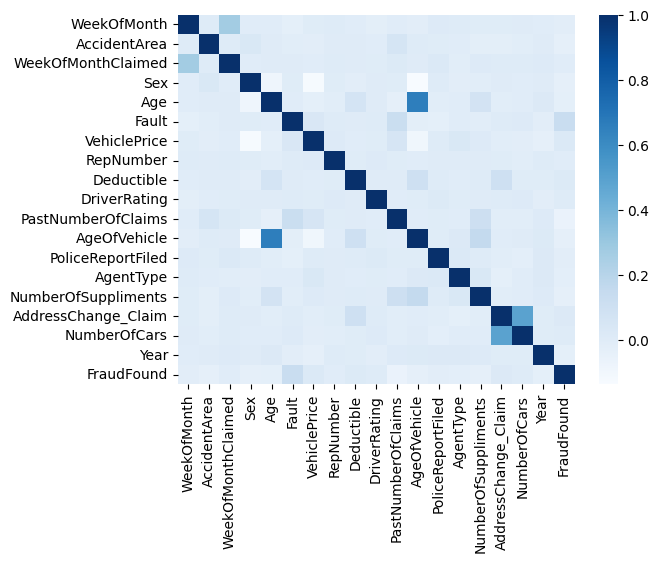

In [151]:
# Calculate correlation between numeric predictors
num_vars = df.select_dtypes(include="int64").columns
corr_mat = df[num_vars].corr()
sns.heatmap(corr_mat, cmap="Blues", annot=False)

- The features themselves are not highly correlated. However, I'll get the variance inflation factor next.

In [152]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# select only numeric variables and add a constant
features = df.select_dtypes(include='int64')
features_with_constant = add_constant(features)

# get vif scores
vif_data = pd.DataFrame()
vif_data['feature'] = features.columns
vif_data['VIF'] = [variance_inflation_factor(features_with_constant.values, i+1) for i in range(len(features.columns))]
vif_data = vif_data.sort_values(by='VIF', ascending=False)

print(vif_data)

                feature       VIF
11         AgeOfVehicle  1.872288
4                   Age  1.788746
15  AddressChange_Claim  1.340631
16         NumberOfCars  1.326936
0           WeekOfMonth  1.084488
2    WeekOfMonthClaimed  1.084255
10   PastNumberOfClaims  1.044489
14  NumberOfSuppliments  1.042916
3                   Sex  1.041895
5                 Fault  1.039896
6          VehiclePrice  1.037652
18           FraudFound  1.029148
8            Deductible  1.024470
1          AccidentArea  1.007424
13            AgentType  1.005713
17                 Year  1.003660
12    PoliceReportFiled  1.003596
9          DriverRating  1.001384
7             RepNumber  1.000861


- There's low multicolinearity in this dataset. I don't necessarily need to use tree-based models in this case.

In [153]:
from scipy.stats import chi2_contingency

def cramers_v(col1, col2):
    contingency = pd.crosstab(df[col1], df[col2])
    chi2, p, dof, expected = chi2_contingency(contingency)
    n = contingency.sum().sum()
    return np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))

<Axes: >

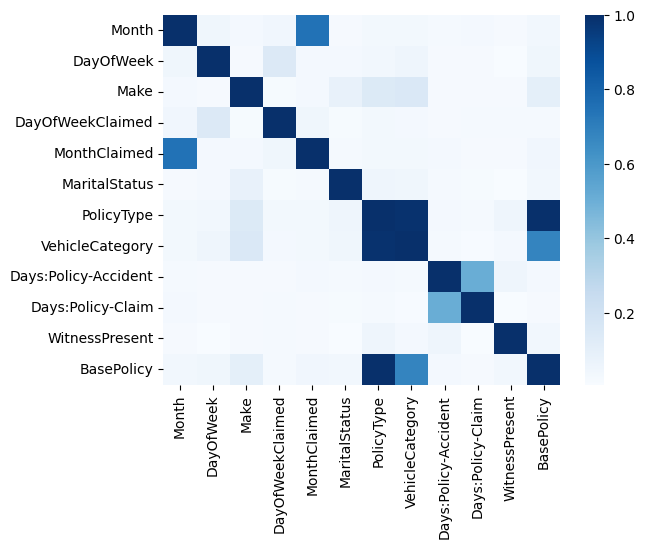

In [154]:
# compute Cramer's V for categorical predictors
cat_cols = df.select_dtypes(include='object').columns

cramers_matrix = pd.DataFrame(
    index=cat_cols,
    columns=cat_cols,
    dtype=float
)

for c1 in cat_cols:
    for c2 in cat_cols:
        if c1 == c2:
            cramers_matrix.loc[c1, c2] = 1.0
        else:
            cramers_matrix.loc[c1, c2] = cramers_v(c1, c2)

# plot the results
sns.heatmap(cramers_matrix, cmap="Blues", annot=False)

In [155]:
strong_pairs = cramers_matrix.where(np.triu(np.ones(cramers_matrix.shape), 1).astype(bool))
strong_pairs = strong_pairs.stack().sort_values(ascending=False)
strong_pairs = strong_pairs[strong_pairs > 0.9]   # threshold example
strong_pairs

PolicyType  BasePolicy         0.997573
            VehicleCategory    0.989030
dtype: float64

- Here there actually seem to be some highly correlated pairs. I'll exclude 'BasePolicy' and 'VehicleCategory' since they are redundant.

In [156]:
df = df.drop('BasePolicy', axis=1)
df = df.drop('VehicleCategory', axis=1)

# Machine Learning

In [157]:
y = df['FraudFound']
X = df.drop(columns=['FraudFound'])

## Logistic Regression

In [158]:
# get lists of the numerical, categorical, and binary columns
int_columns = X.select_dtypes(include=["int64"]).columns

numerical_cols = []
binary_cols = []

for col in int_columns:
    # If it has 2 or fewer unique values, it's binary
    if X[col].nunique() <= 2:
        binary_cols.append(col)
    else:
        numerical_cols.append(col)

categorical_cols = X.select_dtypes(include="object").columns.tolist()

In [159]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(transformers=[
    ('scale', StandardScaler(), numerical_cols),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols),
    ('binary', 'passthrough', binary_cols)
])

In [160]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

In [161]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](28,)","['Month','WeekOfMonth','DayOfWeek',...,'AddressChange_Claim', 'NumberOfCars','Year']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,28
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scale', ...), ('onehot', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainde

In [162]:
from sklearn.metrics import classification_report

y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.987     0.623     0.763      2867
           1      0.120     0.860     0.210       171

    accuracy                          0.636      3038
   macro avg      0.553     0.741     0.487      3038
weighted avg      0.938     0.636     0.732      3038



Recall = 0.85 is quite good but the predictions lack precision. While the model does not make many false negative predictions, it makes quite a lot of false positives. In the case of fraud detection, flagging more cases as fraud in order to capture these highly costly cases may be advantageous.

## Random Forest Classifier

In [163]:
from sklearn.ensemble import RandomForestClassifier

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=150,
                                     max_depth=15,
                                     min_samples_leaf=25,
                                     class_weight='balanced',
                                     random_state=42))
])

In [164]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.989     0.647     0.782      2867
           1      0.129     0.877     0.225       171

    accuracy                          0.660      3038
   macro avg      0.559     0.762     0.503      3038
weighted avg      0.940     0.660     0.751      3038



In [167]:
from sklearn.metrics import f1_score
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
y_proba = pipeline.predict_proba(X_test)[:, 1]

for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_pred = (y_proba >= threshold).astype(int)
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    print(f"Threshold {threshold}: Precision={precision:.3f}, Recall={recall:.3f}, F1={f1:.3f}")

Threshold 0.3: Precision=0.113, Recall=0.977, F1=0.202
Threshold 0.4: Precision=0.121, Recall=0.971, F1=0.216
Threshold 0.5: Precision=0.129, Recall=0.877, F1=0.225
Threshold 0.6: Precision=0.160, Recall=0.491, F1=0.241
Threshold 0.7: Precision=0.345, Recall=0.170, F1=0.227


The random forest classifier performs marginally better than logistic regression. However, the data is clearly limited with such a sharp tradeoff between precision and recall. Proper tuning might lead to slightly better results though. Threshold can stay at 0.5.

# Parameter tuning

In [168]:
import optuna
from sklearn.metrics import recall_score
from sklearn.model_selection import cross_val_score

# define tuning function
def objective(trial):
    params = {"n_estimators": trial.suggest_int("n_estimators", 50, 200),
              "max_depth": trial.suggest_int("max_depth", 5, 30),
              "min_samples_split": trial.suggest_int("min_samples_split", 2, 8),
              "min_samples_leaf": trial.suggest_int("min_samples_leaf", 5, 30),
              "class_weight": 'balanced',
              "random_state": 42}

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(**params))
    ])
    
    pipeline.fit(X_train, y_train)

    # avoid data leakage by using the crossvalidated score and not the test dataset
    scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='recall')
    
    return scores.mean()

In [169]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)
print("Best Params:", study.best_params)
print("Best Recall:", study.best_value)

[I 2026-06-24 18:39:56,658] A new study created in memory with name: no-name-65fffc3d-4c39-4971-b12b-ecfacd526240
[I 2026-06-24 18:39:59,890] Trial 0 finished with value: 0.816680644860684 and parameters: {'n_estimators': 54, 'max_depth': 16, 'min_samples_split': 5, 'min_samples_leaf': 15}. Best is trial 0 with value: 0.816680644860684.
[I 2026-06-24 18:40:06,815] Trial 1 finished with value: 0.8290094119839717 and parameters: {'n_estimators': 135, 'max_depth': 17, 'min_samples_split': 7, 'min_samples_leaf': 19}. Best is trial 1 with value: 0.8290094119839717.
[I 2026-06-24 18:40:17,074] Trial 2 finished with value: 0.8481222626036716 and parameters: {'n_estimators': 196, 'max_depth': 19, 'min_samples_split': 5, 'min_samples_leaf': 22}. Best is trial 2 with value: 0.8481222626036716.
[I 2026-06-24 18:40:22,254] Trial 3 finished with value: 0.8713912962445253 and parameters: {'n_estimators': 105, 'max_depth': 10, 'min_samples_split': 3, 'min_samples_leaf': 29}. Best is trial 3 with valu

Best Params: {'n_estimators': 193, 'max_depth': 5, 'min_samples_split': 2, 'min_samples_leaf': 26}
Best Recall: 0.9137824993010903


In [170]:
# run against the test scores with the best parameters
pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(**study.best_params, class_weight='balanced', random_state=42))
])
    
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.60      0.75      2867
           1       0.12      0.92      0.21       171

    accuracy                           0.62      3038
   macro avg       0.56      0.76      0.48      3038
weighted avg       0.94      0.62      0.72      3038



Tuning slightly increased recall at the expense of precision. The training data just can't explain fraud to such a great extent, so false positives will remain high. The next step is to code the tuning of the random forest classifier into train.py so that it can be run again when new data comes in.

Confusion matrix, without normalization
[[1719 1148]
 [  13  158]]
Normalized confusion matrix
[[0.59958144 0.40041856]
 [0.07602339 0.92397661]]


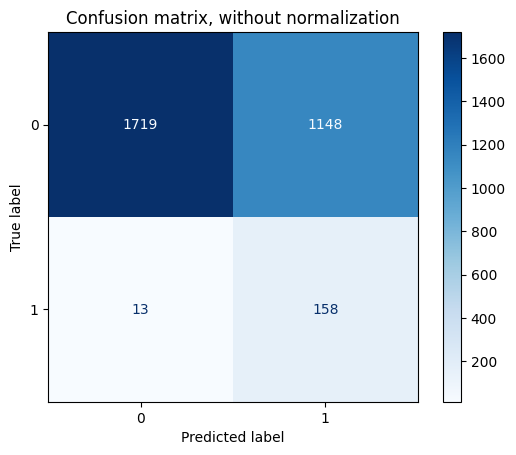

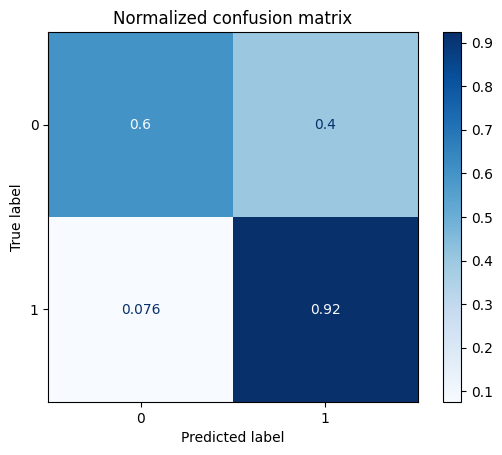

In [173]:
from sklearn.metrics import ConfusionMatrixDisplay

# Plot non-normalized confusion matrix
titles_options = [
    ("Confusion matrix, without normalization", None),
    ("Normalized confusion matrix", "true"),
]
for title, normalize in titles_options:
    disp = ConfusionMatrixDisplay.from_estimator(
        pipeline,
        X_test,
        y_test,
        #display_labels=class_names,
        cmap=plt.cm.Blues,
        normalize=normalize,
    )
    disp.ax_.set_title(title)

    print(title)
    print(disp.confusion_matrix)

plt.show()

# Appendix: Univariate checks

#### Month

Month
Dec    8.333333
Jan    9.150454
Oct    8.463035
Jun    8.566796
Feb    8.210117
Nov    7.788586
Apr    8.300908
Mar    8.819715
Aug    7.308690
Jul    8.151751
May    8.865110
Sep    8.041505
Name: proportion, dtype: float64


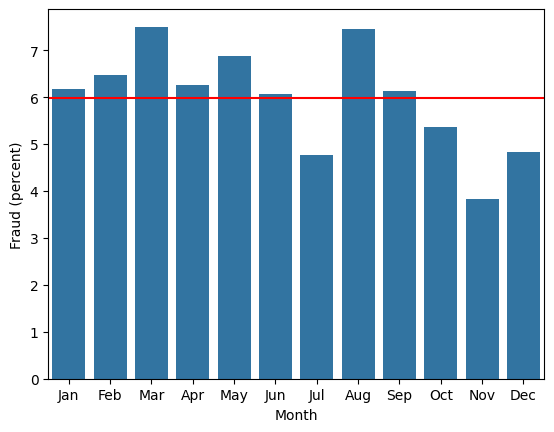

In [15]:
var_show = vars[0]
print(df[var_show].value_counts(normalize=True, sort=False)*100) #  see how data splits over all months

fraud_rate =  df.groupby(var_show)['FraudFound'].mean() * 100 # calculate percentage of fraud within each month
new_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
fraud_rate = fraud_rate.reindex(new_order, axis=0) # sort values

ax = sns.barplot(x=fraud_rate.index, y=fraud_rate.values)
ax.set(ylabel="Fraud (percent)")
ax.axhline(y=df["FraudFound"].mean()*100, color="red")

- Equal distribution of data points. Slight variation between months but no clear linear or other trend. No changes necessary. Use one-hot encoding.

#### WeekOfMonth

WeekOfMonth
5    10.616083
3    23.605707
2    23.073930
4    22.036316
1    20.667964
Name: proportion, dtype: float64


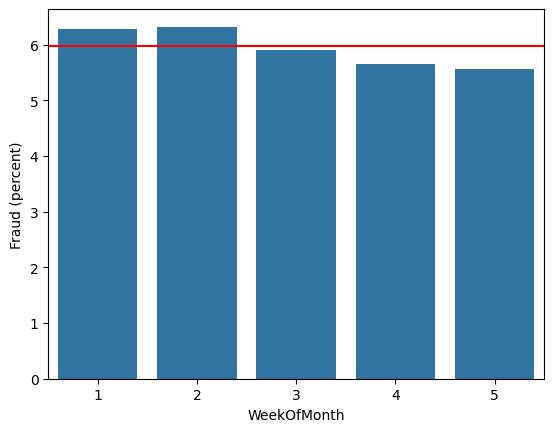

In [16]:
var_show = vars[1]
print(df[var_show].value_counts(normalize=True, sort=False)*100) #  see how data splits over all values

fraud_rate =  df.groupby(var_show)['FraudFound'].mean() * 100 # calculate percentage of fraud within each value

ax = sns.barplot(x=fraud_rate.index, y=fraud_rate.values)
ax.set(ylabel="Fraud (percent)")
ax.axhline(y=df["FraudFound"].mean()*100, color="red")

- The fifth week of the month is not as frequent as the others, but the fraud percentage is quite similar to the fourth week. No changes necessary. Leave as integer variable.

#### DayOfWeek

DayOfWeek
Wednesday    14.001297
Friday       15.856031
Saturday     12.853437
Monday       16.964981
Tuesday      14.915694
Sunday       11.316472
Thursday     14.092088
Name: proportion, dtype: float64


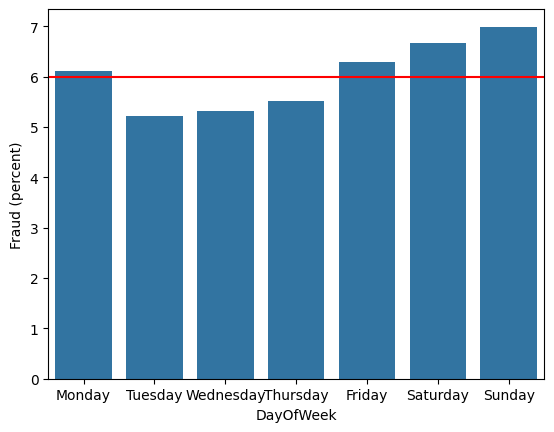

In [17]:
var_show = vars[2]
print(df[var_show].value_counts(normalize=True, sort=False)*100) #  see how data splits over all values

fraud_rate =  df.groupby(var_show)['FraudFound'].mean() * 100 # calculate percentage of fraud within each value
new_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
fraud_rate = fraud_rate.reindex(new_order, axis=0) # sort values

ax = sns.barplot(x=fraud_rate.index, y=fraud_rate.values)
ax.set(ylabel="Fraud (percent)")
ax.axhline(y=df["FraudFound"].mean()*100, color="red")

- Equal distribution of data points. Interestingly, fraud does not happen as often midweek as Monday, Friday or the weekend. Leave as is for now.

#### Make

Make
Pontiac      24.883268
Toyota       20.239948
Honda        18.164721
Mazda        15.265888
Chevrolet    10.901427
Accura        3.060960
Ford          2.918288
VW            1.835279
Dodge         0.706874
Saab          0.700389
Mercury       0.538262
Saturn        0.376135
Nisson        0.194553
BMW           0.097276
Jaguar        0.038911
Porche        0.032425
Mecedes       0.025940
Ferrari       0.012970
Lexus         0.006485
Name: proportion, dtype: float64


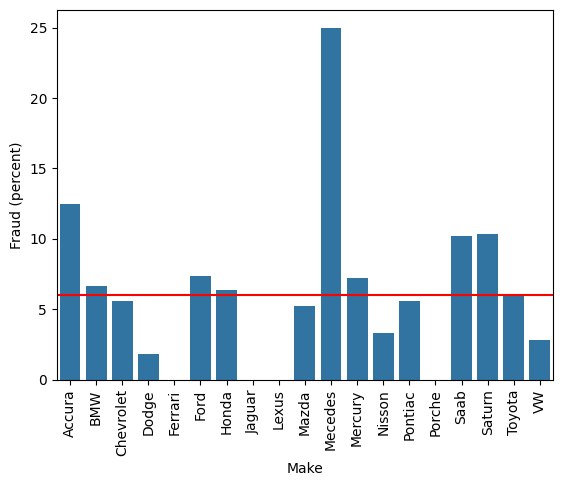

In [18]:
var_show = vars[3]
print(df[var_show].value_counts(normalize=True, sort=True)*100) #  see how data splits over all values

fraud_rate =  df.groupby(var_show)['FraudFound'].mean() * 100 # calculate percentage of fraud within each value

ax = sns.barplot(x=fraud_rate.index, y=fraud_rate.values)
ax.set(ylabel="Fraud (percent)")
ax.axhline(y=df["FraudFound"].mean()*100, color="red")
ax.tick_params(axis='x', rotation=90)

- Some car brands have a high fraud rate but they're also quite rare, such as Mercedes. Even if the signal becomes diluted, I'll group all the rare brands together for model stability. Also, the signal in Mercedes, for example, might just be noise

In [19]:
# Group rare brands together as 'Other'
df["Make"] = df["Make"].replace(('Accura','Ford','VW','Dodge','Saab','Mercury','Saturn','Nissan','BMW','Jaguar','Porsche','Mercedes','Ferrari', 'Lexus'), 'Other')

#### AccidentArea

AccidentArea
Urban    89.636835
Rural    10.363165
Name: proportion, dtype: float64


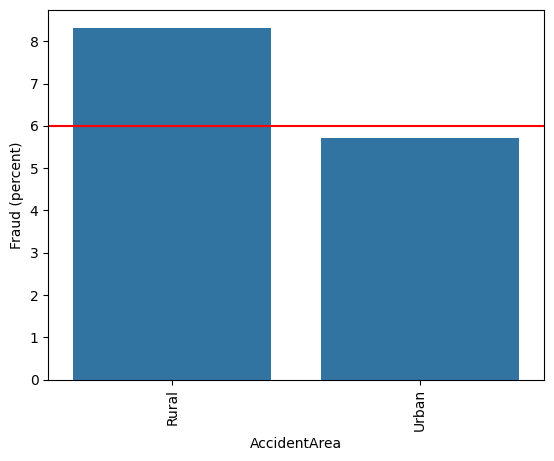

In [20]:
var_show = vars[4]
print(df[var_show].value_counts(normalize=True, sort=True)*100) #  see how data splits over all values

fraud_rate =  df.groupby(var_show)['FraudFound'].mean() * 100 # calculate percentage of fraud within each value

ax = sns.barplot(x=fraud_rate.index, y=fraud_rate.values)
ax.set(ylabel="Fraud (percent)")
ax.axhline(y=df["FraudFound"].mean()*100, color="red")
ax.tick_params(axis='x', rotation=90)

#### DayOfWeekClaimed

DayOfWeekClaimed
Monday       24.364462
Tuesday      21.887160
Wednesday    19.137484
Thursday     17.250324
Friday       16.193256
Saturday      0.823606
Sunday        0.337224
0             0.006485
Name: proportion, dtype: float64


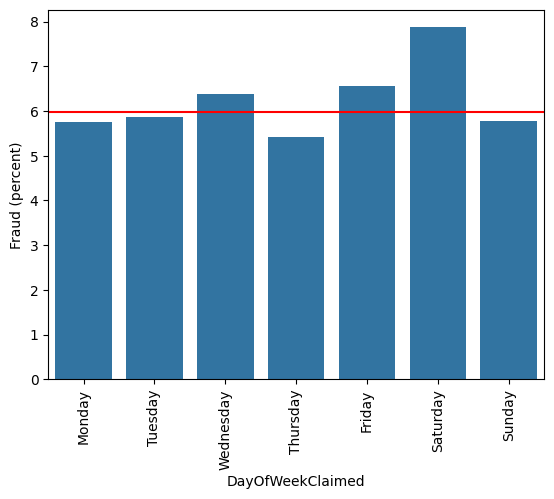

In [21]:
var_show = vars[5]
print(df[var_show].value_counts(normalize=True, sort=True)*100) #  see how data splits over all values

fraud_rate =  df.groupby(var_show)['FraudFound'].mean() * 100 # calculate percentage of fraud within each value
new_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
fraud_rate = fraud_rate.reindex(new_order, axis=0) # sort values

ax = sns.barplot(x=fraud_rate.index, y=fraud_rate.values)
ax.set(ylabel="Fraud (percent)")
ax.axhline(y=df["FraudFound"].mean()*100, color="red")
ax.tick_params(axis='x', rotation=90)

In [22]:
df["DayOfWeekClaimed"] = df["DayOfWeekClaimed"].replace("0", np.nan)

#### MonthClaimed

MonthClaimed
Jan    9.377432
May    9.150454
Mar    8.741894
Oct    8.683528
Jun    8.385214
Feb    8.346304
Nov    8.333333
Apr    8.242542
Sep    8.054475
Jul    7.944228
Dec    7.431907
Aug    7.302205
0      0.006485
Name: proportion, dtype: float64


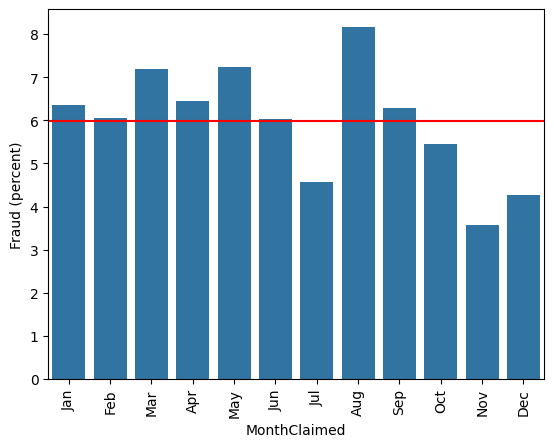

In [23]:
var_show = vars[6]
print(df[var_show].value_counts(normalize=True, sort=True)*100) #  see how data splits over all values

fraud_rate =  df.groupby(var_show)['FraudFound'].mean() * 100 # calculate percentage of fraud within each value
new_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
fraud_rate = fraud_rate.reindex(new_order, axis=0) # sort values

ax = sns.barplot(x=fraud_rate.index, y=fraud_rate.values)
ax.set(ylabel="Fraud (percent)")
ax.axhline(y=df["FraudFound"].mean()*100, color="red")
ax.tick_params(axis='x', rotation=90)

In [24]:
df["MonthClaimed"] = df["MonthClaimed"].replace("0", np.nan)
cramers_v("Month","MonthClaimed")

np.float64(0.7472822683004031)

- 'Month' and 'MonthClaimed' seem to have a very similar pattern but Camer's V shows they're still different enough from each other.'

#### WeekOfMonthClaimed

WeekOfMonthClaimed
2    24.124514
3    23.236057
1    22.373541
4    22.263294
5     8.002594
Name: proportion, dtype: float64


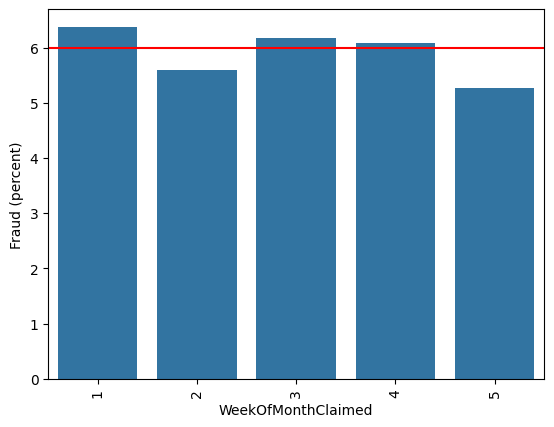

In [25]:
var_show = vars[7]
print(df[var_show].value_counts(normalize=True, sort=True)*100) #  see how data splits over all values

fraud_rate =  df.groupby(var_show)['FraudFound'].mean() * 100 # calculate percentage of fraud within each value

ax = sns.barplot(x=fraud_rate.index, y=fraud_rate.values)
ax.set(ylabel="Fraud (percent)")
ax.axhline(y=df["FraudFound"].mean()*100, color="red")
ax.tick_params(axis='x', rotation=90)

In [26]:
df["DayOfWeekClaimed"] = df["DayOfWeekClaimed"].replace("0", np.nan)

#### Sex

Sex
Male      84.306096
Female    15.693904
Name: proportion, dtype: float64


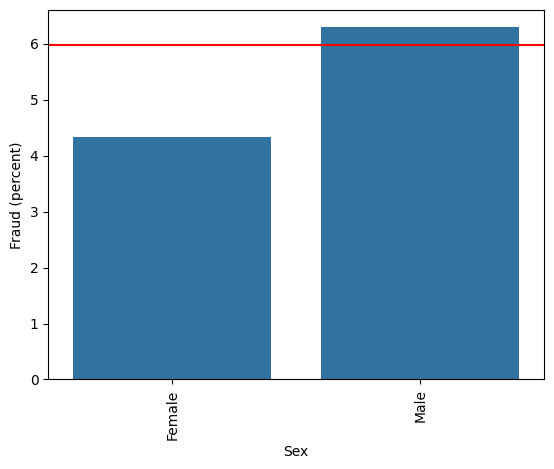

In [27]:
var_show = vars[8]
print(df[var_show].value_counts(normalize=True, sort=True)*100) #  see how data splits over all values

fraud_rate =  df.groupby(var_show)['FraudFound'].mean() * 100 # calculate percentage of fraud within each value

ax = sns.barplot(x=fraud_rate.index, y=fraud_rate.values)
ax.set(ylabel="Fraud (percent)")
ax.axhline(y=df["FraudFound"].mean()*100, color="red")
ax.tick_params(axis='x', rotation=90)

#### MaritalStatus

MaritalStatus
Married     68.904021
Single      30.376135
Divorced     0.492866
Widow        0.226978
Name: proportion, dtype: float64


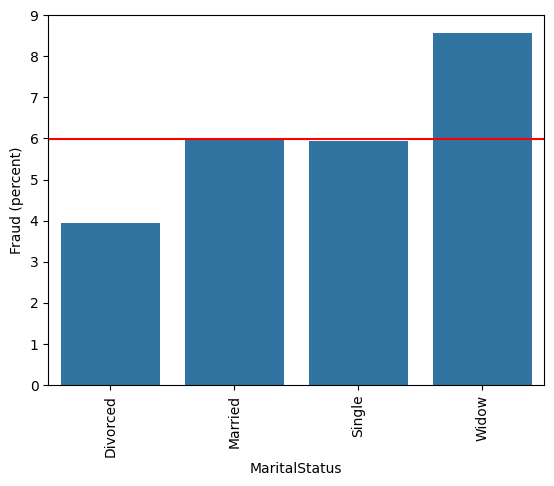

In [28]:
var_show = vars[9]
print(df[var_show].value_counts(normalize=True, sort=True)*100) #  see how data splits over all values

fraud_rate =  df.groupby(var_show)['FraudFound'].mean() * 100 # calculate percentage of fraud within each value

ax = sns.barplot(x=fraud_rate.index, y=fraud_rate.values)
ax.set(ylabel="Fraud (percent)")
ax.axhline(y=df["FraudFound"].mean()*100, color="red")
ax.tick_params(axis='x', rotation=90)

- Slightly elevated/decreased fraud rate for widowed and divorced, but these make up less than 1% of the data. Too unreliable, merge them together as 'other'.

In [29]:
df["MaritalStatus"] = df["MaritalStatus"].replace(("Divorced","Widow"), "Other")

#### Age

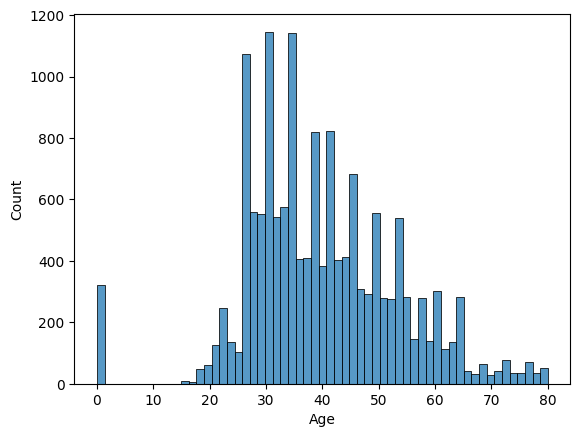

In [30]:
var_show = vars[10]
ax = sns.histplot(df[var_show])

In [31]:
df['Age'] = df['Age'].replace(0,16)

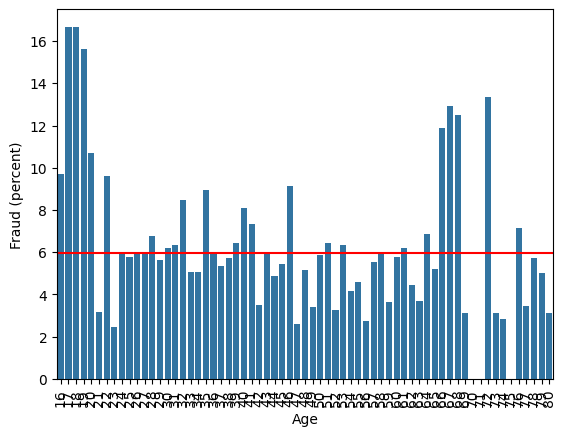

In [32]:
fraud_rate =  df.groupby(var_show)['FraudFound'].mean() * 100 # calculate percentage of fraud within each value
ax = sns.barplot(x=fraud_rate.index, y=fraud_rate.values)
ax.set(ylabel="Fraud (percent)")
ax.axhline(y=df["FraudFound"].mean()*100, color="red")
ax.tick_params(axis='x', rotation=90)

- There doesn't seem to be a linear relationship between age and fraud rate. However, younger and older people seem more likely to commit fraud. Perhaps use XGBoost instead of linear regression later.

#### Fault

Fault
Policy Holder    72.827497
Third Party      27.172503
Name: proportion, dtype: float64


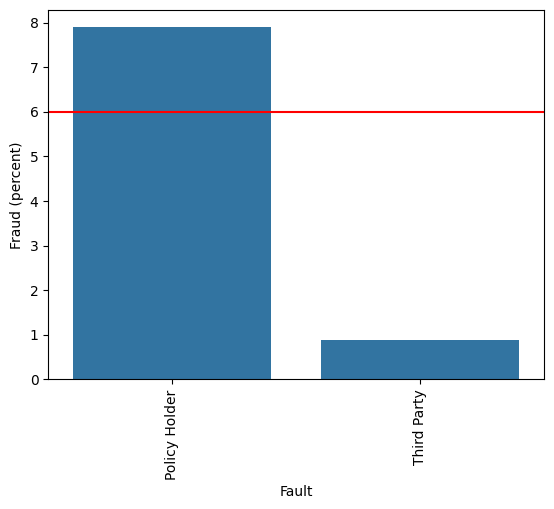

In [33]:
var_show = vars[11]
print(df[var_show].value_counts(normalize=True, sort=True)*100) #  see how data splits over all values

fraud_rate =  df.groupby(var_show)['FraudFound'].mean() * 100 # calculate percentage of fraud within each value

ax = sns.barplot(x=fraud_rate.index, y=fraud_rate.values)
ax.set(ylabel="Fraud (percent)")
ax.axhline(y=df["FraudFound"].mean()*100, color="red")
ax.tick_params(axis='x', rotation=90)

#### PolicyType

PolicyType
Sedan - Collision       36.212711
Sedan - Liability       32.341115
Sedan - All Perils      26.504540
Sport - Collision        2.256809
Utility - All Perils     2.204929
Utility - Collision      0.194553
Sport - All Perils       0.142672
Utility - Liability      0.136187
Sport - Liability        0.006485
Name: proportion, dtype: float64


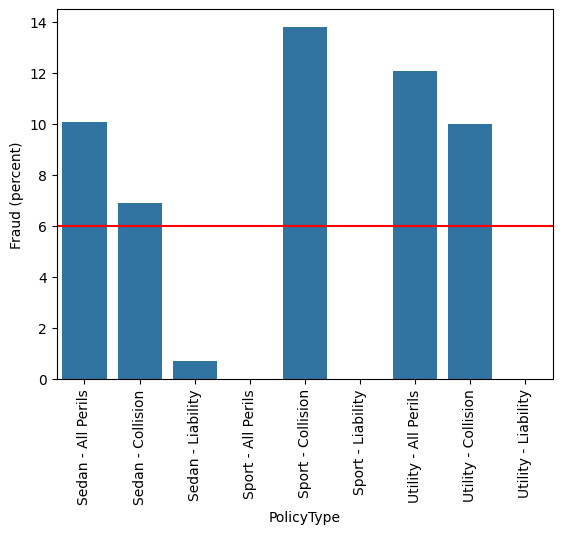

In [34]:
var_show = vars[12]
print(df[var_show].value_counts(normalize=True, sort=True)*100) #  see how data splits over all values

fraud_rate =  df.groupby(var_show)['FraudFound'].mean() * 100 # calculate percentage of fraud within each value

ax = sns.barplot(x=fraud_rate.index, y=fraud_rate.values)
ax.set(ylabel="Fraud (percent)")
ax.axhline(y=df["FraudFound"].mean()*100, color="red")
ax.tick_params(axis='x', rotation=90)

In [35]:
df["PolicyType"] = df["PolicyType"].replace(("Utility - Collision", "Sport - All Perils", "Utility - Liability", "Sport - Liability"), "Other")

#### VehicleCategory

VehicleCategory
Sedan      62.717250
Sport      34.747082
Utility     2.535668
Name: proportion, dtype: float64


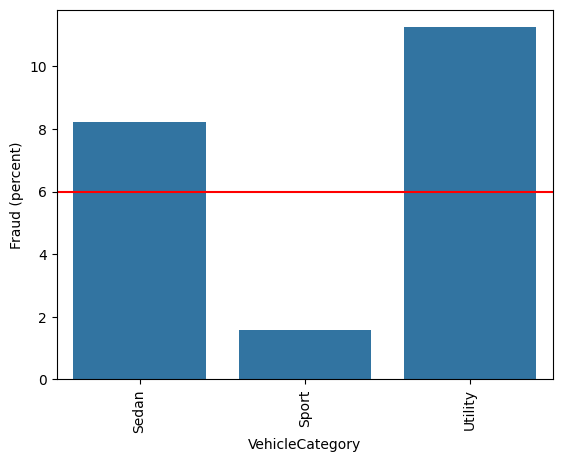

In [36]:
var_show = vars[13]
print(df[var_show].value_counts(normalize=True, sort=True)*100) #  see how data splits over all values

fraud_rate =  df.groupby(var_show)['FraudFound'].mean() * 100 # calculate percentage of fraud within each value

ax = sns.barplot(x=fraud_rate.index, y=fraud_rate.values)
ax.set(ylabel="Fraud (percent)")
ax.axhline(y=df["FraudFound"].mean()*100, color="red")
ax.tick_params(axis='x', rotation=90)

#### VehiclePrice

VehiclePrice
20,000 to 29,000    52.392996
30,000 to 39,000    22.911803
more than 69,000    14.033722
less than 20,000     7.107652
40,000 to 59,000     2.989624
60,000 to 69,000     0.564202
Name: proportion, dtype: float64


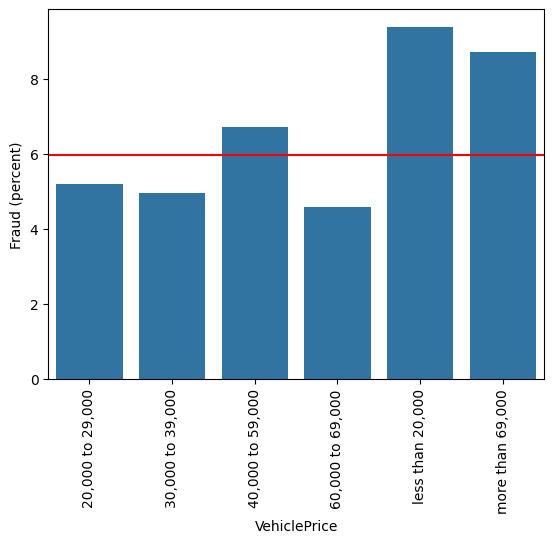

In [37]:
var_show = vars[14]
print(df[var_show].value_counts(normalize=True, sort=True)*100) #  see how data splits over all values

fraud_rate =  df.groupby(var_show)['FraudFound'].mean() * 100 # calculate percentage of fraud within each value

ax = sns.barplot(x=fraud_rate.index, y=fraud_rate.values)
ax.set(ylabel="Fraud (percent)")
ax.axhline(y=df["FraudFound"].mean()*100, color="red")
ax.tick_params(axis='x', rotation=90)

In [38]:
df['VehiclePrice'] = df['VehiclePrice'].replace(("more than 69,000", "60,000 to 69,000"), "more than 60,000")

#### RepNumber

RepNumber
7     6.932555
9     6.478599
5     6.400778
1     6.400778
10    6.394293
15    6.335927
12    6.335927
16    6.271077
2     6.199741
3     6.154345
11    6.147860
6     6.108949
14    6.102464
8     6.037613
4     5.914397
13    5.784695
Name: proportion, dtype: float64


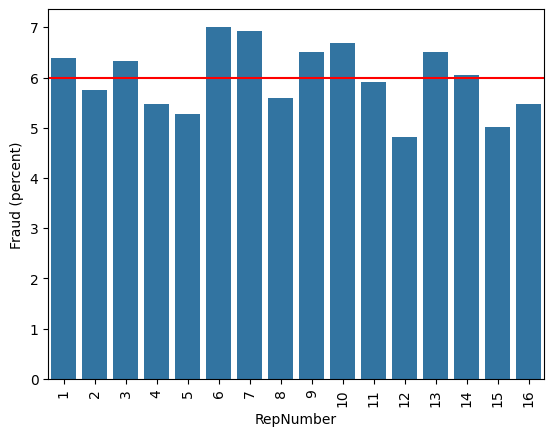

In [39]:
var_show = vars[15]
print(df[var_show].value_counts(normalize=True, sort=True)*100) #  see how data splits over all values

fraud_rate =  df.groupby(var_show)['FraudFound'].mean() * 100 # calculate percentage of fraud within each value

ax = sns.barplot(x=fraud_rate.index, y=fraud_rate.values)
ax.set(ylabel="Fraud (percent)")
ax.axhline(y=df["FraudFound"].mean()*100, color="red")
ax.tick_params(axis='x', rotation=90)

#### Deductible

Deductible
400    96.225681
700     2.016861
500     1.705577
300     0.051881
Name: proportion, dtype: float64


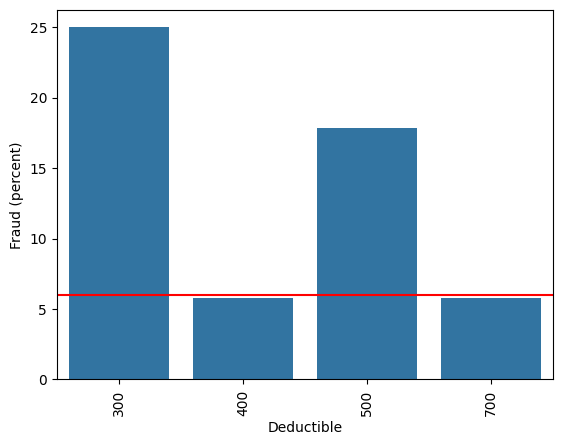

In [40]:
var_show = vars[16]
print(df[var_show].value_counts(normalize=True, sort=True)*100) #  see how data splits over all values

fraud_rate =  df.groupby(var_show)['FraudFound'].mean() * 100 # calculate percentage of fraud within each value

ax = sns.barplot(x=fraud_rate.index, y=fraud_rate.values)
ax.set(ylabel="Fraud (percent)")
ax.axhline(y=df["FraudFound"].mean()*100, color="red")
ax.tick_params(axis='x', rotation=90)

- There seems to be some signal in 300 and 500 but the vast majority of the data, more than 96%, show no variability in deductibles. Better to drop than to risk fitting to noise

#### DriverRating

DriverRating
1    25.577173
3    25.188067
2    24.649805
4    24.584955
Name: proportion, dtype: float64


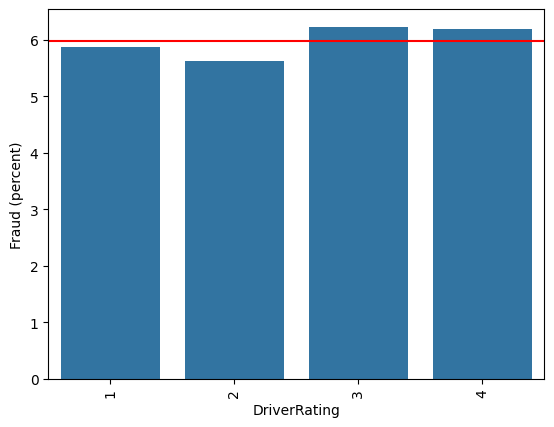

In [41]:
var_show = vars[17]
print(df[var_show].value_counts(normalize=True, sort=True)*100) #  see how data splits over all values

fraud_rate =  df.groupby(var_show)['FraudFound'].mean() * 100 # calculate percentage of fraud within each value

ax = sns.barplot(x=fraud_rate.index, y=fraud_rate.values)
ax.set(ylabel="Fraud (percent)")
ax.axhline(y=df["FraudFound"].mean()*100, color="red")
ax.tick_params(axis='x', rotation=90)

#### Days:Policy-Accident

Days:Policy-Accident
more than 30    98.878080
none             0.356680
8 to 15          0.356680
15 to 30         0.317769
1 to 7           0.090791
Name: proportion, dtype: float64


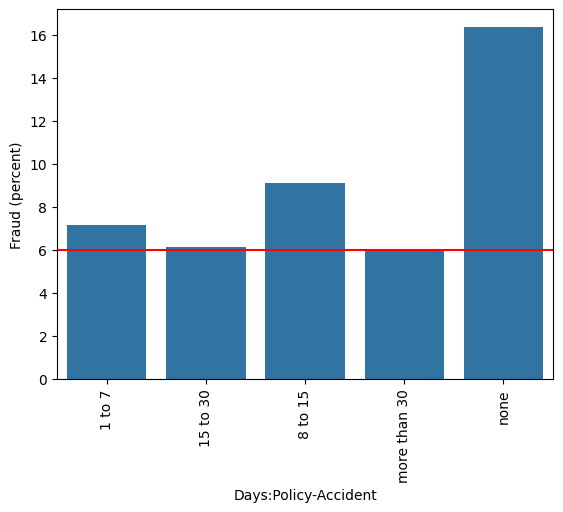

In [42]:
var_show = vars[18]
print(df[var_show].value_counts(normalize=True, sort=True)*100) #  see how data splits over all values

fraud_rate =  df.groupby(var_show)['FraudFound'].mean() * 100 # calculate percentage of fraud within each value

ax = sns.barplot(x=fraud_rate.index, y=fraud_rate.values)
ax.set(ylabel="Fraud (percent)")
ax.axhline(y=df["FraudFound"].mean()*100, color="red")
ax.tick_params(axis='x', rotation=90)

- Again, some signal but in less than 1% of the data. Better to drop this since it might just be noise.

#### Days:Policy-Claim

Days:Policy-Claim
more than 30    99.494163
15 to 30         0.363165
8 to 15          0.136187
none             0.006485
Name: proportion, dtype: float64


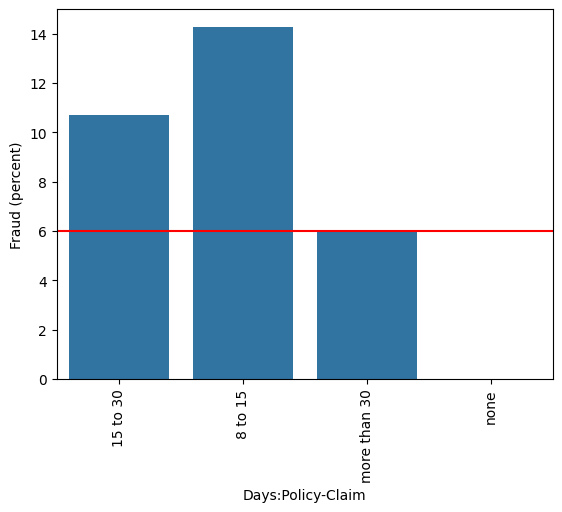

In [43]:
var_show = vars[19]
print(df[var_show].value_counts(normalize=True, sort=True)*100) #  see how data splits over all values

fraud_rate =  df.groupby(var_show)['FraudFound'].mean() * 100 # calculate percentage of fraud within each value

ax = sns.barplot(x=fraud_rate.index, y=fraud_rate.values)
ax.set(ylabel="Fraud (percent)")
ax.axhline(y=df["FraudFound"].mean()*100, color="red")
ax.tick_params(axis='x', rotation=90)

- Same issue as before, the variability in categories is just too low. Drop it.

#### Days:Policy-Accident

Days:Policy-Accident
more than 30    98.878080
none             0.356680
8 to 15          0.356680
15 to 30         0.317769
1 to 7           0.090791
Name: proportion, dtype: float64


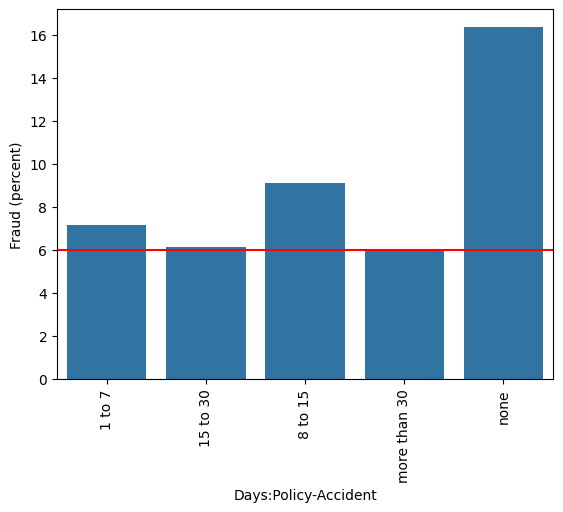

In [44]:
var_show = vars[18]
print(df[var_show].value_counts(normalize=True, sort=True)*100) #  see how data splits over all values

fraud_rate =  df.groupby(var_show)['FraudFound'].mean() * 100 # calculate percentage of fraud within each value

ax = sns.barplot(x=fraud_rate.index, y=fraud_rate.values)
ax.set(ylabel="Fraud (percent)")
ax.axhline(y=df["FraudFound"].mean()*100, color="red")
ax.tick_params(axis='x', rotation=90)

- Same as before, the variability in categories is just too low. Drop it.

#### Days:Policy-Claim

Days:Policy-Claim
more than 30    99.494163
15 to 30         0.363165
8 to 15          0.136187
none             0.006485
Name: proportion, dtype: float64


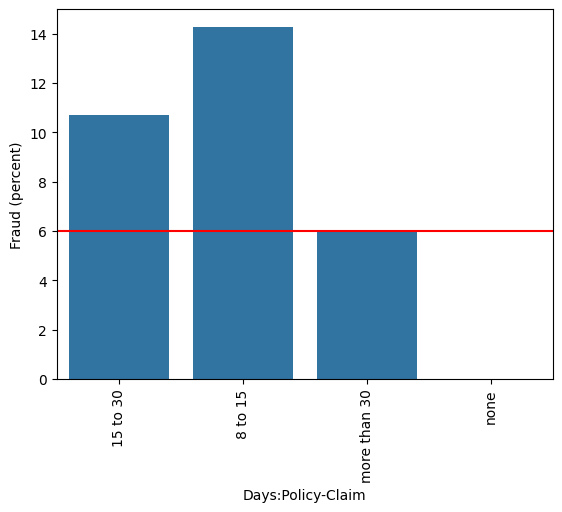

In [45]:
var_show = vars[19]
print(df[var_show].value_counts(normalize=True, sort=True)*100) #  see how data splits over all values

fraud_rate =  df.groupby(var_show)['FraudFound'].mean() * 100 # calculate percentage of fraud within each value

ax = sns.barplot(x=fraud_rate.index, y=fraud_rate.values)
ax.set(ylabel="Fraud (percent)")
ax.axhline(y=df["FraudFound"].mean()*100, color="red")
ax.tick_params(axis='x', rotation=90)

- Same as before, the variability in categories is just too low. Drop it.

#### PastNumberOfClaims

PastNumberOfClaims
2 to 4         35.570687
none           28.223087
1              23.171206
more than 4    13.035019
Name: proportion, dtype: float64


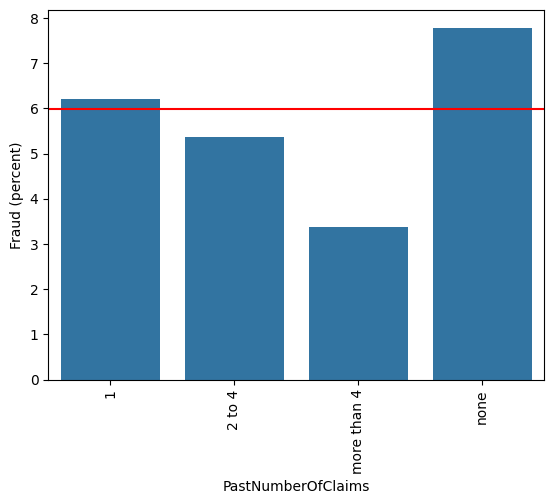

In [46]:
var_show = vars[20]
print(df[var_show].value_counts(normalize=True, sort=True)*100) #  see how data splits over all values

fraud_rate =  df.groupby(var_show)['FraudFound'].mean() * 100 # calculate percentage of fraud within each value

ax = sns.barplot(x=fraud_rate.index, y=fraud_rate.values)
ax.set(ylabel="Fraud (percent)")
ax.axhline(y=df["FraudFound"].mean()*100, color="red")
ax.tick_params(axis='x', rotation=90)

- Interesting pattern, the more claims were entered before, the less likely it is that someone was involved in fraud. Keep it but use ordinal encoding

#### AgeOfVehicle

AgeOfVehicle
7 years        37.658885
more than 7    25.817121
6 years        22.360571
5 years         8.800259
new             2.418936
4 years         1.485084
3 years         0.985733
2 years         0.473411
Name: proportion, dtype: float64


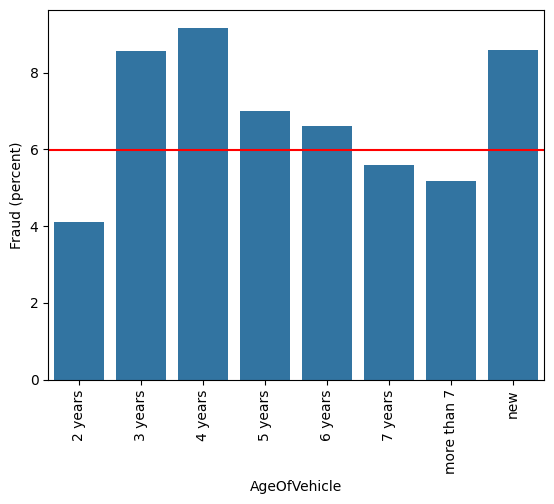

In [47]:
var_show = vars[21]
print(df[var_show].value_counts(normalize=True, sort=True)*100) #  see how data splits over all values

fraud_rate =  df.groupby(var_show)['FraudFound'].mean() * 100 # calculate percentage of fraud within each value

ax = sns.barplot(x=fraud_rate.index, y=fraud_rate.values)
ax.set(ylabel="Fraud (percent)")
ax.axhline(y=df["FraudFound"].mean()*100, color="red")
ax.tick_params(axis='x', rotation=90)

In [48]:
df["AgeOfVehicle"] = df["AgeOfVehicle"].replace(("2 years", "3 years"), "between 2 and 3 years")

#### PoliceReportFiled

PoliceReportFiled
No     97.224384
Yes     2.775616
Name: proportion, dtype: float64


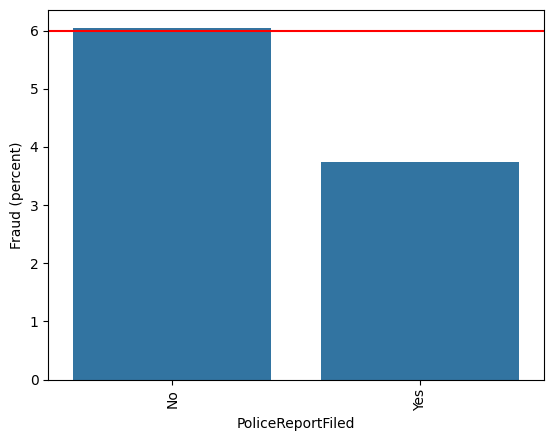

In [49]:
var_show = vars[22]
print(df[var_show].value_counts(normalize=True, sort=True)*100) #  see how data splits over all values

fraud_rate =  df.groupby(var_show)['FraudFound'].mean() * 100 # calculate percentage of fraud within each value

ax = sns.barplot(x=fraud_rate.index, y=fraud_rate.values)
ax.set(ylabel="Fraud (percent)")
ax.axhline(y=df["FraudFound"].mean()*100, color="red")
ax.tick_params(axis='x', rotation=90)

#### WitnessPresent

WitnessPresent
No     99.435798
Yes     0.564202
Name: proportion, dtype: float64


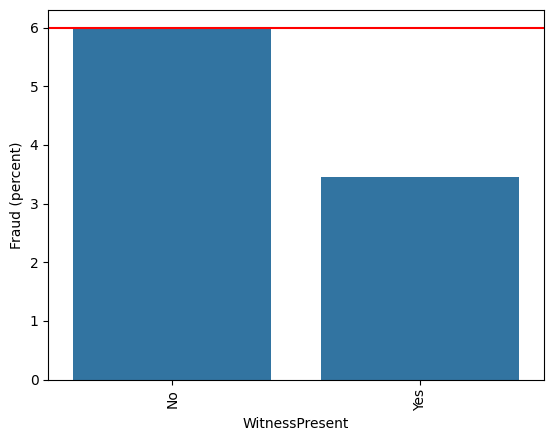

In [50]:
var_show = vars[23]
print(df[var_show].value_counts(normalize=True, sort=True)*100) #  see how data splits over all values

fraud_rate =  df.groupby(var_show)['FraudFound'].mean() * 100 # calculate percentage of fraud within each value

ax = sns.barplot(x=fraud_rate.index, y=fraud_rate.values)
ax.set(ylabel="Fraud (percent)")
ax.axhline(y=df["FraudFound"].mean()*100, color="red")
ax.tick_params(axis='x', rotation=90)

- Barely any variability in the levels of WitnessPresent. Drop it

#### AgentType

AgentType
External    98.437095
Internal     1.562905
Name: proportion, dtype: float64


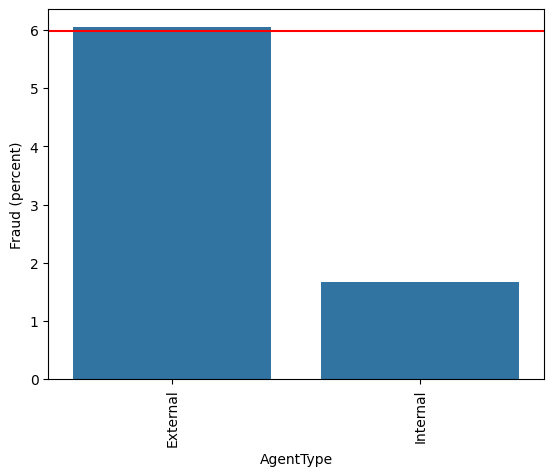

In [51]:
var_show = vars[24]
print(df[var_show].value_counts(normalize=True, sort=True)*100) #  see how data splits over all values

fraud_rate =  df.groupby(var_show)['FraudFound'].mean() * 100 # calculate percentage of fraud within each value

ax = sns.barplot(x=fraud_rate.index, y=fraud_rate.values)
ax.set(ylabel="Fraud (percent)")
ax.axhline(y=df["FraudFound"].mean()*100, color="red")
ax.tick_params(axis='x', rotation=90)

#### NumberOfSuppliments

NumberOfSuppliments
none           45.700389
more than 5    25.077821
1 to 2         16.141375
3 to 5         13.080415
Name: proportion, dtype: float64


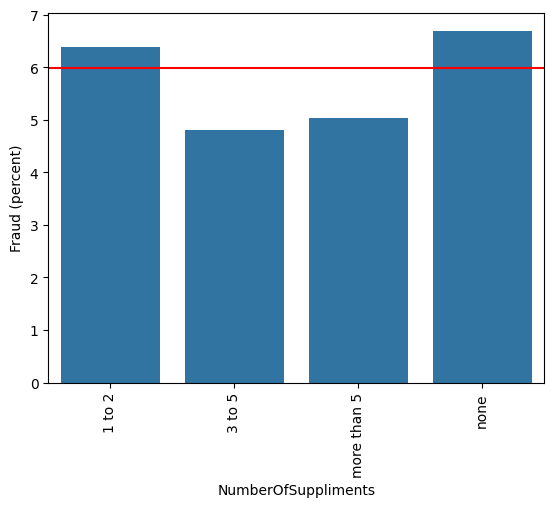

In [52]:
var_show = vars[25]
print(df[var_show].value_counts(normalize=True, sort=True)*100) #  see how data splits over all values

fraud_rate =  df.groupby(var_show)['FraudFound'].mean() * 100 # calculate percentage of fraud within each value

ax = sns.barplot(x=fraud_rate.index, y=fraud_rate.values)
ax.set(ylabel="Fraud (percent)")
ax.axhline(y=df["FraudFound"].mean()*100, color="red")
ax.tick_params(axis='x', rotation=90)

#### AddressChange-Claim

AddressChange-Claim
no change         92.892348
4 to 8 years       4.092088
2 to 3 years       1.887160
1 year             1.102464
under 6 months     0.025940
Name: proportion, dtype: float64


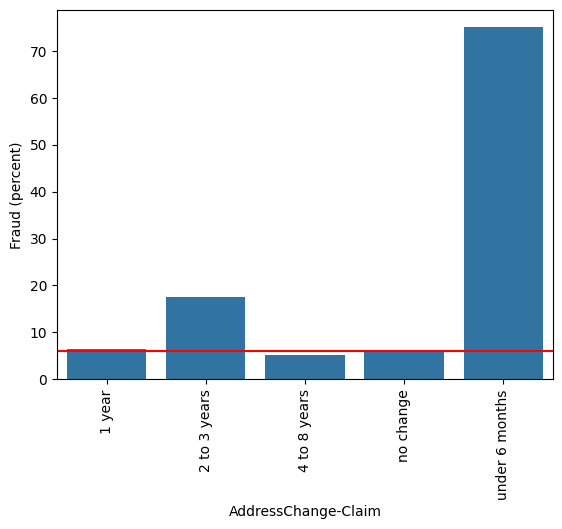

In [53]:
var_show = vars[26]
print(df[var_show].value_counts(normalize=True, sort=True)*100) #  see how data splits over all values

fraud_rate =  df.groupby(var_show)['FraudFound'].mean() * 100 # calculate percentage of fraud within each value

ax = sns.barplot(x=fraud_rate.index, y=fraud_rate.values)
ax.set(ylabel="Fraud (percent)")
ax.axhline(y=df["FraudFound"].mean()*100, color="red")
ax.tick_params(axis='x', rotation=90)

- Another case where the signal looks massive, but it's only 4 data points in 'Under 6 months'. Merge it to '1 year'.

In [54]:
df["AddressChange-Claim"] = df["AddressChange-Claim"].replace(("under 6 months", "1 year"), "6 months to 1 year")

#### NumberOfCars

NumberOfCars
1 vehicle      92.840467
2 vehicles      4.597925
3 to 4          2.412451
5 to 8          0.136187
more than 8     0.012970
Name: proportion, dtype: float64


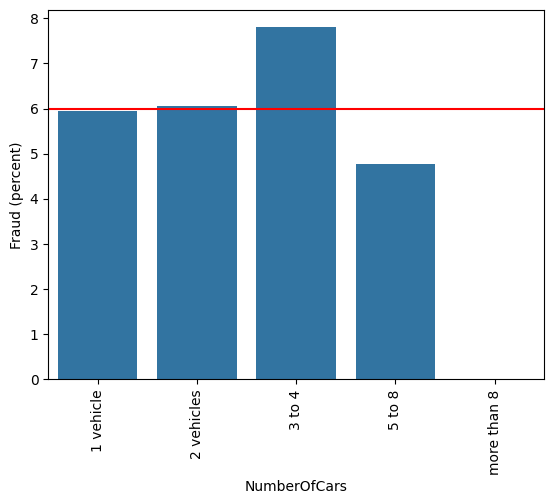

In [55]:
var_show = vars[27]
print(df[var_show].value_counts(normalize=True, sort=True)*100) #  see how data splits over all values

fraud_rate =  df.groupby(var_show)['FraudFound'].mean() * 100 # calculate percentage of fraud within each value

ax = sns.barplot(x=fraud_rate.index, y=fraud_rate.values)
ax.set(ylabel="Fraud (percent)")
ax.axhline(y=df["FraudFound"].mean()*100, color="red")
ax.tick_params(axis='x', rotation=90)

#### Year

Year
1994    39.831388
1995    33.690013
1996    26.478599
Name: proportion, dtype: float64


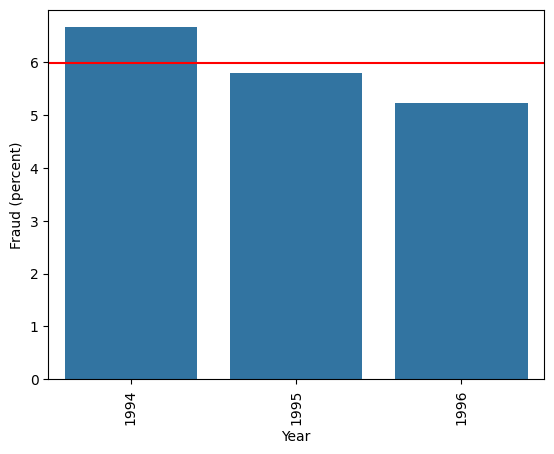

In [57]:
var_show = vars[28]
print(df[var_show].value_counts(normalize=True, sort=True)*100) #  see how data splits over all values

fraud_rate =  df.groupby(var_show)['FraudFound'].mean() * 100 # calculate percentage of fraud within each value

ax = sns.barplot(x=fraud_rate.index, y=fraud_rate.values)
ax.set(ylabel="Fraud (percent)")
ax.axhline(y=df["FraudFound"].mean()*100, color="red")
ax.tick_params(axis='x', rotation=90)

#### BasePolicy

BasePolicy
Collision     38.664073
Liability     32.483787
All Perils    28.852140
Name: proportion, dtype: float64


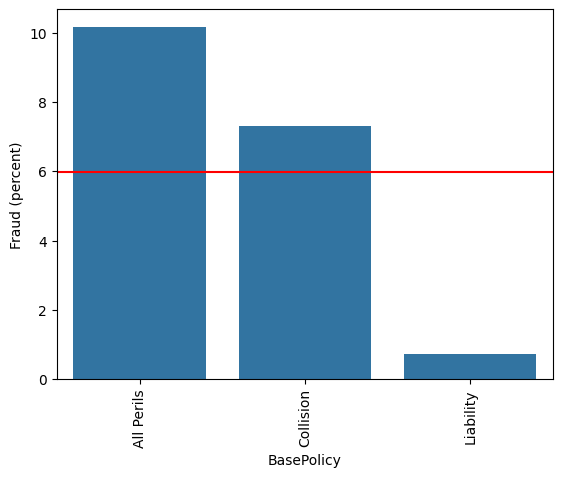

In [59]:
var_show = vars[29]
print(df[var_show].value_counts(normalize=True, sort=True)*100) #  see how data splits over all values

fraud_rate =  df.groupby(var_show)['FraudFound'].mean() * 100 # calculate percentage of fraud within each value

ax = sns.barplot(x=fraud_rate.index, y=fraud_rate.values)
ax.set(ylabel="Fraud (percent)")
ax.axhline(y=df["FraudFound"].mean()*100, color="red")
ax.tick_params(axis='x', rotation=90)